In [2]:
import matplotlib.pyplot as plt
from matplotlib.text import Text
import numpy as np
import glob
import pandas as pd
import os
from datetime import datetime, timezone, timedelta

In [3]:
#Old Calibration Loding in data:

calibration_frequency = 410

data_dir_old = f"/home/scratch/dbautist/TEST/{calibration_frequency}/"


csvs = glob.glob(f"{data_dir_old}/2025*/*.csv")
csvs.sort()

In [4]:
len(csvs)

350

In [5]:
#New Calibration loading in data:

calibration_frequency = 410

data_dir_new = f"/home/scratch/mburchil/REU2026/chime-reduction/test_output"
csvs_new = glob.glob(f"{data_dir_new}/2025*/*.csv")
csvs_new.sort()

In [6]:
print(csvs_new)

['/home/scratch/mburchil/REU2026/chime-reduction/test_output/2025_001/2025_001.csv', '/home/scratch/mburchil/REU2026/chime-reduction/test_output/2025_002/2025_002.csv', '/home/scratch/mburchil/REU2026/chime-reduction/test_output/2025_003/2025_003.csv', '/home/scratch/mburchil/REU2026/chime-reduction/test_output/2025_004/2025_004.csv', '/home/scratch/mburchil/REU2026/chime-reduction/test_output/2025_005/2025_005.csv', '/home/scratch/mburchil/REU2026/chime-reduction/test_output/2025_006/2025_006.csv', '/home/scratch/mburchil/REU2026/chime-reduction/test_output/2025_007/2025_007.csv', '/home/scratch/mburchil/REU2026/chime-reduction/test_output/2025_008/2025_008.csv', '/home/scratch/mburchil/REU2026/chime-reduction/test_output/2025_009/2025_009.csv', '/home/scratch/mburchil/REU2026/chime-reduction/test_output/2025_010/2025_010.csv', '/home/scratch/mburchil/REU2026/chime-reduction/test_output/2025_011/2025_011.csv', '/home/scratch/mburchil/REU2026/chime-reduction/test_output/2025_012/2025_0

In [7]:
#Old Excluding dates:

# exclude the following days due to extreme RFI/ power outage in early June 2025
to_exclude = ["2025_087", "2025_163", "2025_176", "2025_150" "2025_151",
             "2025_150", "2025_158"]
for bad_day in to_exclude:
    try:
        csvs_new.remove(f"/home/scratch/mburchil/REU2026/chime-reduction/test_output/{bad_day}/{bad_day}.csv")
    except:
        pass

In [8]:
#New excluding dates:

#to_exclude = ["2025_087", "2025_155", "2025_163", "2025_176", "2025_150" "2025_151", "2025_152",
 #             "2025_153", "2025_154", "2025_145", "2025_146", "2025_147", "2025_148", "2025_149", "2025_150"]
#for bad_day in to_exclude:
 #   try:
  #      csvs.remove(f"/home/scratch/mburchil/test_output/{bad_day}/{bad_day}.csv")
   # except:
    #    pass

In [9]:
print(csvs_new)

['/home/scratch/mburchil/REU2026/chime-reduction/test_output/2025_001/2025_001.csv', '/home/scratch/mburchil/REU2026/chime-reduction/test_output/2025_002/2025_002.csv', '/home/scratch/mburchil/REU2026/chime-reduction/test_output/2025_003/2025_003.csv', '/home/scratch/mburchil/REU2026/chime-reduction/test_output/2025_004/2025_004.csv', '/home/scratch/mburchil/REU2026/chime-reduction/test_output/2025_005/2025_005.csv', '/home/scratch/mburchil/REU2026/chime-reduction/test_output/2025_006/2025_006.csv', '/home/scratch/mburchil/REU2026/chime-reduction/test_output/2025_007/2025_007.csv', '/home/scratch/mburchil/REU2026/chime-reduction/test_output/2025_008/2025_008.csv', '/home/scratch/mburchil/REU2026/chime-reduction/test_output/2025_009/2025_009.csv', '/home/scratch/mburchil/REU2026/chime-reduction/test_output/2025_010/2025_010.csv', '/home/scratch/mburchil/REU2026/chime-reduction/test_output/2025_011/2025_011.csv', '/home/scratch/mburchil/REU2026/chime-reduction/test_output/2025_012/2025_0

In [10]:
#Old lists using old stuff:

full_dates = []
all_dates = []

first_day = os.path.basename(csvs[0])[:-4]
latest_day = os.path.basename(csvs[-1])[:-4]

date_difference = datetime.strptime(latest_day, "%Y_%j") - datetime.strptime(first_day, "%Y_%j")
n_days = date_difference.days
one_day = timedelta(days=1)

for i in range(n_days+1):
    full_dates.append((datetime.strptime(first_day, "%Y_%j") + i*one_day).strftime("%Y_%j"))
    all_dates.append((datetime.strptime(first_day, "%Y_%j") + i*one_day))

In [11]:
#New days using new stuff:

full_dates = []
all_dates = []

first_day = os.path.basename(csvs[0])[:-4]
latest_day = os.path.basename(csvs[-1])[:-4]

date_difference = datetime.strptime(latest_day, "%Y_%j") - datetime.strptime(first_day, "%Y_%j")
n_days = date_difference.days
one_day = timedelta(days=1)

for i in range(n_days+1):
    full_dates.append((datetime.strptime(first_day, "%Y_%j") + i*one_day).strftime("%Y_%j"))
    all_dates.append((datetime.strptime(first_day, "%Y_%j") + i*one_day))

In [12]:
#Old sorting

timestamps = []
# full_dates = []
# years = []
for i in range(len(csvs)):
    timestamps.append(int(os.path.basename(csvs[i]).replace(".csv", "")[-3::]))

# bad calibrations
mean_flux = []
date = []

mask = []
grid = np.empty((len(full_dates), 1024))
missing_dates = []
for i in range(len(full_dates)):
    year = full_dates[i][:4]
    date_str = full_dates[i][-3:]
    csv_path = f"{data_dir_old}/{year}_{date_str}/{year}_{date_str}.csv".replace("//", "/")
    if csv_path in csvs:#os.path.exists(csv_path):
        df = pd.read_csv(csv_path)
        grid[i] = np.array(df["intensity"], dtype=float)
        mask.append(np.zeros(1024))

        # bookkeeping
        mean_flux.append(np.nanmean(df["intensity"]))
        date.append(f"{year}_{date_str}")
    else:
        print(csv_path)
        grid[i] = np.empty(1024)
        mask.append(np.ones(1024))
        missing_dates.append(f"{year}_{date_str}")
        print("no data... masking day")

masked_grid_old = np.ma.masked_array(grid, mask=mask)

/home/scratch/dbautist/TEST/410/2025_087/2025_087.csv
no data... masking day
/home/scratch/dbautist/TEST/410/2025_095/2025_095.csv
no data... masking day
/home/scratch/dbautist/TEST/410/2025_096/2025_096.csv
no data... masking day
/home/scratch/dbautist/TEST/410/2025_097/2025_097.csv
no data... masking day
/home/scratch/dbautist/TEST/410/2025_104/2025_104.csv
no data... masking day
/home/scratch/dbautist/TEST/410/2025_105/2025_105.csv
no data... masking day
/home/scratch/dbautist/TEST/410/2025_107/2025_107.csv
no data... masking day
/home/scratch/dbautist/TEST/410/2025_150/2025_150.csv
no data... masking day
/home/scratch/dbautist/TEST/410/2025_151/2025_151.csv
no data... masking day
/home/scratch/dbautist/TEST/410/2025_152/2025_152.csv
no data... masking day
/home/scratch/dbautist/TEST/410/2025_158/2025_158.csv
no data... masking day
/home/scratch/dbautist/TEST/410/2025_163/2025_163.csv
no data... masking day
/home/scratch/dbautist/TEST/410/2025_164/2025_164.csv
no data... masking day

In [13]:
print(mask)

[array([0., 0., 0., ..., 0., 0., 0.]), array([0., 0., 0., ..., 0., 0., 0.]), array([0., 0., 0., ..., 0., 0., 0.]), array([0., 0., 0., ..., 0., 0., 0.]), array([0., 0., 0., ..., 0., 0., 0.]), array([0., 0., 0., ..., 0., 0., 0.]), array([0., 0., 0., ..., 0., 0., 0.]), array([0., 0., 0., ..., 0., 0., 0.]), array([0., 0., 0., ..., 0., 0., 0.]), array([0., 0., 0., ..., 0., 0., 0.]), array([0., 0., 0., ..., 0., 0., 0.]), array([0., 0., 0., ..., 0., 0., 0.]), array([0., 0., 0., ..., 0., 0., 0.]), array([0., 0., 0., ..., 0., 0., 0.]), array([0., 0., 0., ..., 0., 0., 0.]), array([0., 0., 0., ..., 0., 0., 0.]), array([0., 0., 0., ..., 0., 0., 0.]), array([0., 0., 0., ..., 0., 0., 0.]), array([0., 0., 0., ..., 0., 0., 0.]), array([0., 0., 0., ..., 0., 0., 0.]), array([0., 0., 0., ..., 0., 0., 0.]), array([0., 0., 0., ..., 0., 0., 0.]), array([0., 0., 0., ..., 0., 0., 0.]), array([0., 0., 0., ..., 0., 0., 0.]), array([0., 0., 0., ..., 0., 0., 0.]), array([0., 0., 0., ..., 0., 0., 0.]), array([0., 

In [14]:
#New sorting:

timestamps = []
# full_dates = []
# years = []
for i in range(len(csvs_new)):
    timestamps.append(int(os.path.basename(csvs_new[i]).replace(".csv", "")[-3::]))

# bad calibrations
mean_flux_new = []
date = []

mask = []
grid = np.empty((len(full_dates), 1024))
missing_dates_new = []
for i in range(len(full_dates)):
    year = full_dates[i][:4]
    date_str = full_dates[i][-3:]
    csv_path_new = f"{data_dir_new}/{year}_{date_str}/{year}_{date_str}.csv".replace("//", "/")
    if csv_path_new in csvs_new:#os.path.exists(csv_path):
        df = pd.read_csv(csv_path_new)
        grid[i] = np.array(df["intensity"], dtype=float)
        mask.append(np.zeros(1024))

        # bookkeeping
        mean_flux_new.append(np.nanmean(df["intensity"]))
        date.append(f"{year}_{date_str}")
    else:
        print(csv_path_new)
        grid[i] = np.empty(1024)
        mask.append(np.ones(1024))
        missing_dates_new.append(f"{year}_{date_str}")
        print("no data... masking day")

masked_grid_new = np.ma.masked_array(grid, mask=mask)

/home/scratch/mburchil/REU2026/chime-reduction/test_output/2025_087/2025_087.csv
no data... masking day
/home/scratch/mburchil/REU2026/chime-reduction/test_output/2025_095/2025_095.csv
no data... masking day
/home/scratch/mburchil/REU2026/chime-reduction/test_output/2025_096/2025_096.csv
no data... masking day
/home/scratch/mburchil/REU2026/chime-reduction/test_output/2025_097/2025_097.csv
no data... masking day
/home/scratch/mburchil/REU2026/chime-reduction/test_output/2025_104/2025_104.csv
no data... masking day
/home/scratch/mburchil/REU2026/chime-reduction/test_output/2025_105/2025_105.csv
no data... masking day
/home/scratch/mburchil/REU2026/chime-reduction/test_output/2025_107/2025_107.csv
no data... masking day
/home/scratch/mburchil/REU2026/chime-reduction/test_output/2025_150/2025_150.csv
no data... masking day
/home/scratch/mburchil/REU2026/chime-reduction/test_output/2025_151/2025_151.csv
no data... masking day
/home/scratch/mburchil/REU2026/chime-reduction/test_output/2025_

In [15]:
print(mean_flux_new)

[285178.9606484375, 453093.62726660154, 342745.7755576172, 410725.2975585938, 367381.9927597656, 355878.9726640625, 420558.1376816406, 413286.40830175777, 276507.638109375, 1427095.251859375, 417177.18696386716, 543004.7198798829, 494310.4683066406, 458890.5298291015, 776243.0340488281, 428381.62275000004, 437289.5598613281, 598491.2232714843, 648796.2328046875, 2988914.6022939454, 860197.9722236329, 1170592.5164404297, 645574.1691796874, 382622.79202832025, 352980.4768896484, 323012.4645986328, 342200.335493164, 337542.88193554693, 303526.96851757815, 320996.07586035156, 339619.5237050781, 392404.6011748047, 334171.508071289, 524588.5028320312, 1440554.115038086, 1423692.2189580076, 1007038.4673447264, 566653.885788086, 723003.1965771484, 425645.8827373047, 387332.4025078125, 365855.1872207031, 334579.0606464844, 324139.4295488281, 326329.29293652344, 235949.09041308594, 270571.31721875, 366431.8702128907, 398290.39913574216, 451318.9941220704, 447169.0643320313, 613321.963038086, 119

In [16]:
#old datetime

from datetime import datetime
human_readable_dates_old = []
for date in full_dates:
    time_obj = datetime.strptime(date, "%Y_%j")
    MM_DD_YY = time_obj.strftime("%m-%d-%y")
    human_readable_dates_old.append(MM_DD_YY)

In [17]:
#new datetime

from datetime import datetime
human_readable_dates_new = []
for date in full_dates:
    time_obj = datetime.strptime(date, "%Y_%j")
    MM_DD_YY = time_obj.strftime("%m-%d-%y")
    human_readable_dates_new.append(MM_DD_YY)

total tick labels: 365


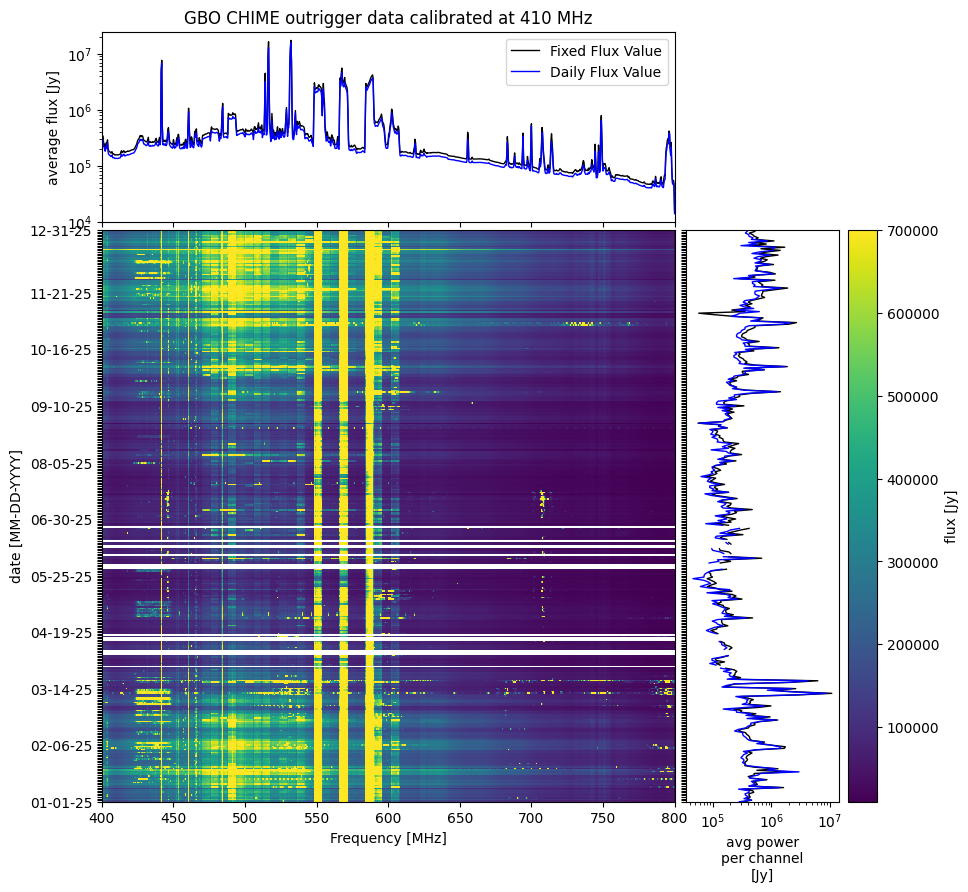

In [18]:
unit = "Jy"
human_readable = True

frequency = df["frequency"]
average_spectrum_old = np.nanmean(masked_grid_old, axis=0)  #for old method with one fixed frequency
average_spectrum_new = np.nanmean(masked_grid_new, axis=0)  #for new method with a daily frequency

time_series_old = np.nanmean(masked_grid_old, axis=1) #timeseries with old data
time_series_new = np.nanmean(masked_grid_new, axis=1) #timeseries with new data 

extent = [400, 800, min(all_dates), max(all_dates)]

height = 10
ratio = 3
fig = plt.figure(figsize=(10,height))
gs = fig.add_gridspec(2,2, hspace=0.02, wspace=0.03, width_ratios=[ratio,1], height_ratios=[1,ratio])
(ax1, ax2), (ax3, ax4) = gs.subplots(sharex="col", sharey="row")

ax1.set_title(f"GBO CHIME outrigger data calibrated at {calibration_frequency} MHz")
ax1.semilogy(frequency, average_spectrum_old, color="black", linewidth=1, label='Fixed Flux Value') #plotting old data
ax1.semilogy(frequency, average_spectrum_new, color='blue', linewidth=1, label='Daily Flux Value')  #plotting new data
ax1.set_ylabel(f"average flux [{unit}]")
ax1.legend()

ax2.set_visible(not ax2)

wf = ax3.imshow(masked_grid_new, aspect="auto", extent=extent, origin="lower", vmin=1e4, vmax=7e5, interpolation="none")#vmin=0, vmax=4e7,)
ax3.set_xlabel("Frequency [MHz]")
ax3.set_ylabel("date [YYYY_ddd]")
ax3.set_yticks(all_dates)

if human_readable:
    ax3.set_yticklabels(human_readable_dates_new)
    ax3.set_ylabel("date [MM-DD-YYYY]")
else:
    ax3.set_yticklabels(full_dates)
    ax3.set_ylabel("date [YYYY_ddd]")
count = 0
separator_index = len(full_dates)//10
if separator_index == 0:
    separator_index = 1
print("total tick labels:", len(ax3.get_yticklabels()))
total_ticks = len(ax3.get_yticklabels())
for i,label in enumerate(ax3.get_yticklabels()):
    # print(count)
    too_close = (total_ticks - i) < int(0.05 * total_ticks)
    if (count%separator_index != 0 or too_close) and count != (total_ticks - 1):
        label.set_visible(False)
    count += 1

ax4.plot(time_series_old, all_dates, color="black", linewidth=1) #plotting old data
ax4.plot(time_series_new, all_dates, color="blue", linewidth=1) #plotting new data 

ax4.set_xlabel(f"avg power\nper channel\n[{unit}]")
ax4.set_xscale("log")
# plt.savefig(f"/users/dbautist/AAS_poster/calibrated_{calibration_frequency}.png", bbox_inches='tight', transparent=False)#f"/users/dbautist/CHIME_landing_directory/confluence/calibrated_{calibration_frequency}.png", bbox_inches='tight', transparent=False)
# plt.savefig(f"/users/dbautist/AAS_poster/calibrated_{calibration_frequency}.pdf", bbox_inches='tight', transparent=False)
fig.colorbar(wf, ax=ax4, label=f'flux [{unit}]', location='right')
plt.show()

In [19]:
print(masked_grid_new)


[[308654.905 263371.234 221615.193 ... 43943.713 38341.276 11837.644]
 [431398.444 396931.821 360215.633 ... 63148.097 55279.969 17038.536]
 [310458.082 280966.946 260705.077 ... 48531.507 42405.375 13113.333]
 ...
 [387994.116 429585.041 352055.388 ... 59716.214 52198.141 16055.358]
 [351998.683 381539.044 319346.634 ... 56152.428 49182.027 15170.156]
 [373438.533 424237.291 317265.271 ... 56191.944 48960.217 15084.49]]


In [20]:
masked_grid_new[69]
csvs[69]
#time_series_new[69]

'/home/scratch/dbautist/TEST/410/2025_070/2025_070.csv'

In [21]:
from scipy.optimize import curve_fit

def wave(x, P, phi, A, B):
    yy = A * np.cos(2*np.pi/P*x + phi) + B
    return yy

Text(0, 0.5, 'avg power\nper channel\n[Jy]')

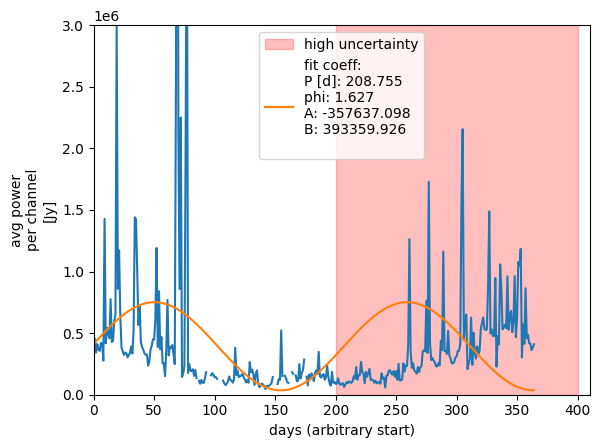

In [22]:
#At only a frequency of 410 MHz

time = time_series_old - time_series_new

xx = np.arange(len(time))
p0 = (365,1,1e6,0.5e6)
bounds = ((100, 0, 0.1e6, 0), 
          (700, 7, 0.75e6, 0.5e6)
         )

plt.figure()

# setting uncertainties
uncertainties = np.ones_like(xx)*1e5
# roc = np.diff(time_series)
# dy_mask = (np.abs(roc) > 0.14e6).data
# uncertainties[1:][dy_mask] = 1e5
uncertainties[200:400] = 1e6
uncertainties[600:770] = 1e6

plt.axvspan(200, 400, alpha=0.25, color="red", label='high uncertainty')
plt.axvspan(600, 770, alpha=0.25, color="red")
# =================================== #

coef_letters = ["P [d]" , "phi", "A", "B"]

coeff, cov = curve_fit(wave, xx[~time_series_new.mask], time_series_new.data[~time_series_new.mask], 
                       p0=p0,
                       sigma=uncertainties[~time_series_new.mask]
                       ) # bounds=bounds)

label_string = ""
for i in range(len(coef_letters)):
    label_string += coef_letters[i] + ": " + str(np.round(coeff[i], decimals=3)) + '\n'


plt.plot(xx, time_series_new)

plt.plot(xx, wave(xx, *coeff), label=f"fit coeff:\n{label_string}")
# plt.yscale("log")
plt.ylim(0, 0.3e7)
plt.legend()
plt.xlabel("days (arbitrary start)")
plt.xlim(0, 410)
plt.ylabel(f"avg power\nper channel\n[{unit}]")

In [23]:
print(time_series_new)
time = time_series_old - time_series_new
time

np.max(time)

[285178.9606484375 453093.62726660154 342745.7755576172 410725.2975585938
 367381.9927597656 355878.9726640625 420558.1376816406 413286.40830175777
 276507.638109375 1427095.251859375 417177.18696386716 543004.7198798829
 494310.4683066406 458890.5298291015 776243.0340488281 428381.62275000004
 437289.5598613281 598491.2232714843 648796.2328046875 2988914.6022939454
 860197.9722236329 1170592.5164404297 645574.1691796874 382622.79202832025
 352980.4768896484 323012.4645986328 342200.335493164 337542.88193554693
 303526.96851757815 320996.07586035156 339619.5237050781 392404.6011748047
 334171.508071289 524588.5028320312 1440554.115038086 1423692.2189580076
 1007038.4673447264 566653.885788086 723003.1965771484 425645.8827373047
 387332.4025078125 365855.1872207031 334579.0606464844 324139.4295488281
 326329.29293652344 235949.09041308594 270571.31721875 366431.8702128907
 398290.39913574216 451318.9941220704 447169.0643320313 613321.963038086
 1190707.4875585937 386707.58996582025 8395

2017654.2235214878

In [24]:
coef_letters = ["P [d]" , "phi", "A", "B"]

for i in range(len(coef_letters)):
    if coef_letters[i] == "phi":
        print(coef_letters[i] + "\t: " + str(np.round(coeff[i], decimals=3)) + "\t\t+/- " + str(np.round(cov[i,i], decimals=3)))
    else:
        print(coef_letters[i] + "\t: " + str(np.round(coeff[i], decimals=3)) + "\t+/- " + str(np.round(cov[i,i], decimals=3)))

P [d]	: 208.755	+/- 344.903
phi	: 1.627		+/- 0.096
A	: -357637.098	+/- 3474445134.178
B	: 393359.926	+/- 1704714376.587


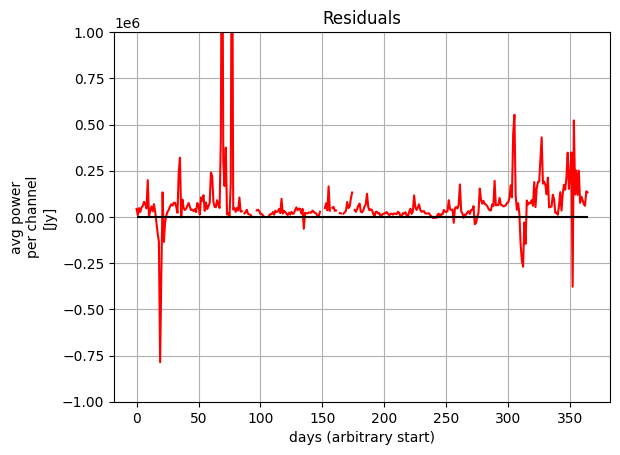

In [25]:
#residuals = time_series_old - wave(xx, *coeff)
residuals = time_series_old - time_series_new

plt.figure()
plt.title("Residuals")
plt.plot(xx, residuals, color="red")
plt.hlines(0, xx.min(), xx.max(), color="black")
plt.xlabel("days (arbitrary start)")
plt.ylabel(f"avg power\nper channel\n[{unit}]")
plt.ylim(-1e6, 1e6)
plt.grid()

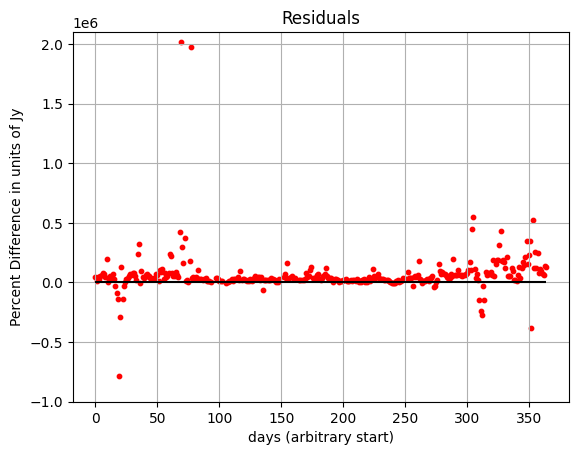

In [26]:
#residuals = time_series_old - wave(xx, *coeff)
residuals = time

plt.figure()
plt.title("Residuals")
plt.scatter(xx, residuals, color="red", s=10)
plt.hlines(0, xx.min(), xx.max(), color="black")
plt.xlabel("days (arbitrary start)")
plt.ylabel(f"Percent Difference in units of {unit}")
plt.ylim(-1e6, 2.1e6)
plt.grid()

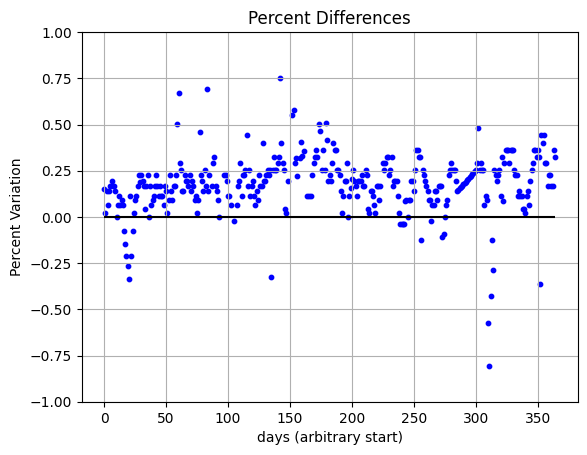

In [49]:
#residuals = time_series_old - wave(xx, *coeff)
percent_diff = (time_series_old - time_series_new) / time_series_new

percent_differences = time / percent_diff

plt.figure()
plt.title("Percent Differences")
plt.scatter(xx, percent_diff, color="blue", s=10)
plt.hlines(0, xx.min(), xx.max(), color="black")
plt.xlabel("days (arbitrary start)")
plt.ylabel(f"Percent Variation")
plt.ylim(-1, 1)
plt.grid()

In [44]:
len(time_series_old + time_series_new)

365

In [28]:
sd = np.std(residuals)
print(sd)
np.sum((residuals / sd) > 1)

178556.59835897147


29

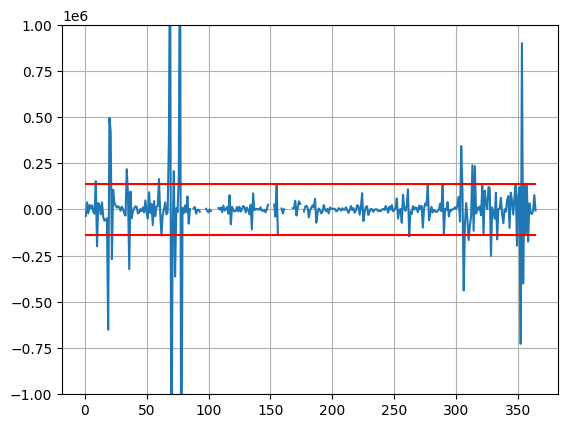

In [29]:
roc = np.diff(time) #Difference in between timeseries old and new 
limit = 0.14e6

plt.figure()
plt.plot(xx[1:], roc)
plt.ylim(-1e6, 1e6)
plt.hlines(-limit, xx.min(), xx.max(), color="red")
plt.hlines(limit, xx.min(), xx.max() , color="red")
plt.grid()

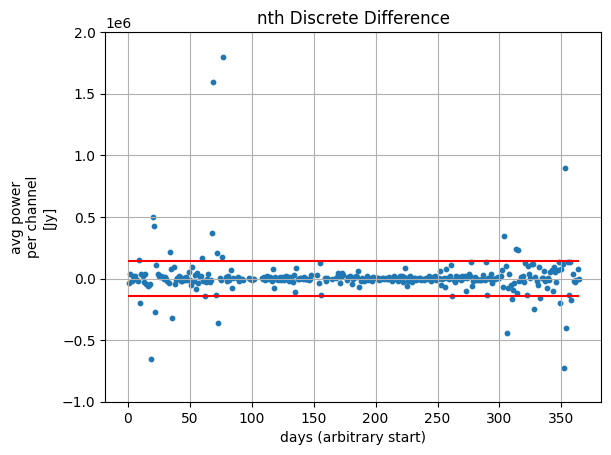

In [30]:
roc = np.diff(time) #Difference in between timeseries old and new 
limit = 0.14e6

plt.figure()
plt.title("nth Discrete Difference")
plt.scatter(xx[1:], roc, s=10)
plt.xlabel("days (arbitrary start)")
plt.ylabel(f"avg power\nper channel\n[{unit}]")
plt.ylim(-1e6, 2e6)
plt.hlines(-limit, xx.min(), xx.max(), color="red")
plt.hlines(limit, xx.min(), xx.max() , color="red")
plt.grid()

In [31]:
print(masked_grid_new)

[[308654.905 263371.234 221615.193 ... 43943.713 38341.276 11837.644]
 [431398.444 396931.821 360215.633 ... 63148.097 55279.969 17038.536]
 [310458.082 280966.946 260705.077 ... 48531.507 42405.375 13113.333]
 ...
 [387994.116 429585.041 352055.388 ... 59716.214 52198.141 16055.358]
 [351998.683 381539.044 319346.634 ... 56152.428 49182.027 15170.156]
 [373438.533 424237.291 317265.271 ... 56191.944 48960.217 15084.49]]


In [32]:
len(time_series_new)

365

In [33]:
len(time)

365

In [34]:
print(time)

[43607.432080078055 9439.44901074213 47824.99081445311 26786.43041015626
 51262.59916015627 59313.157791015634 82060.11771777342 68881.06242382823
 46084.60336425784 199129.5598740233 -0.0028964843950234354
 35413.34610937489 56171.636283203145 29927.633929687552 68999.35520605475
 27937.917349609314 -33002.99935253902 -88472.64003710932
 -136037.95104687498 -786556.6099482421 -290814.7262001954
 133021.77109570312 -135362.3561093749 -28877.215964843752
 7353.738785156282 28712.206006835913 38886.383074218815 56257.12695214845
 68293.55642480461 61229.19727050781 76414.39223339845 76566.7487939453
 55695.24929199228 22322.913653320284 240092.35332324216 320330.7563867187
 -2439.833848632872 94442.32288964838 47152.39030957036 37835.19399511715
 44015.048644531285 60975.86631152348 75280.28922363283 54023.23819238285
 37082.8733642578 39324.84778125002 30746.740751953097 41639.98714160145
 25975.46360644535 75219.83592382807 62395.689294921875 12777.548796874937
 105840.68683886714 8700

In [35]:
df = pd.DataFrame(time)
df
df.to_csv("Time.csv")
df

,0
0,43607.432080
1,9439.449011
2,47824.990814
3,26786.430410
4,51262.599160
...,...
360,93642.814025
361,68939.971257
362,60350.047948
363,138481.086964


In [36]:
ratio = time_series_old / time_series_new
ratio

masked_array(data=[1.1529125149377213, 1.0208333298962686,
                   1.1395348804420595, 1.0652173863391867,
                   1.1395348715245206, 1.1666666545286597,
                   1.1951219352694877, 1.1666666530527063,
                   1.16666665586297, 1.1395348766065725,
                   0.9999999930569444, 1.0652173817516883,
                   1.1136363477707245, 1.0652173709944137,
                   1.0888888559117356, 1.0652173572952583,
                   0.9245282705514286, 0.8521738722357557,
                   0.7903225324555366, 0.7368420598753233,
                   0.6619211674628432, 1.1136362732782534,
                   0.7903225336890787, 0.9245282388648025,
                   1.0208332734148786, 1.088888848430394,
                   1.113636309029848, 1.166666607304996,
                   1.2249999621396064, 1.190747494673877,
                   1.2249999982325983, 1.1951219444540535,
                   1.1666666605224487, 1.042553188895312,
    

In [37]:
pd.set_option('display.width', None)

df = pd.DataFrame({
    'Old' : time_series_old,
    'New' : time_series_new,
    'difference' : time,
    'ratio' : ratio
})

df.to_csv("Time_difference_ratio.csv")

difference = df
too_large = difference.sort_values(by='difference', ascending=False)[:21]

too_small = difference.sort_values(by='difference', ascending=True)[:13]

print(too_large)
print(too_small)

day_70 = difference["difference"][70]
print(day_70)

              Old           New    difference     ratio
69   1.088482e+07  8.867162e+06  2.017654e+06  1.227542
77   6.274541e+06  4.296594e+06  1.977946e+06  1.460352
305  2.708285e+06  2.155574e+06  5.527116e+05  1.256410
353  1.706115e+06  1.183835e+06  5.222801e+05  1.441176
304  2.002628e+06  1.553058e+06  4.495698e+05  1.289474
327  1.917748e+06  1.487233e+06  4.305149e+05  1.289474
68   2.943805e+06  2.524299e+06  4.195056e+05  1.166187
72   2.625520e+06  2.250445e+06  3.750743e+05  1.166667
351  1.424811e+06  1.075878e+06  3.489332e+05  1.324324
348  1.310574e+06  9.628708e+05  3.477033e+05  1.361111
35   1.744023e+06  1.423692e+06  3.203308e+05  1.225000
326  1.182044e+06  8.684404e+05  3.136035e+05  1.361111
70   2.448320e+06  2.148526e+06  2.997944e+05  1.139535
355  8.226940e+05  5.708489e+05  2.518451e+05  1.441176
357  1.114449e+06  8.642663e+05  2.501823e+05  1.289474
60   5.975492e+05  3.574274e+05  2.401218e+05  1.671806
34   1.680646e+06  1.440554e+06  2.400924e+05  1

In [38]:
df

,Old,New,difference,ratio
0,328786.392729,285178.960648,43607.432080,1.152913
1,462533.076277,453093.627267,9439.449011,1.020833
2,390570.766372,342745.775558,47824.990814,1.139535
3,437511.727969,410725.297559,26786.430410,1.065217
4,418644.591920,367381.992760,51262.599160,1.139535
...,...,...,...,...
360,509833.178163,416190.364138,93642.814025,1.225000
361,482579.925737,413639.954480,68939.971257,1.166667
362,422450.447632,362100.399684,60350.047948,1.166667
363,521967.233246,383486.146282,138481.086964,1.361111


In [39]:
#Statistics:

q1, q3 = np.percentile(time, [25, 75])
iqr = q3 - q1

lower = q1 - (1.5*iqr)
upper = q3 + (1.5*iqr)

outlier = (time < lower) | (time > upper)
outliers = time[outlier]

print(outliers)

[]


/users/mburchil/.conda/envs/chime/lib/python3.12/site-packages/numpy/lib/function_base.py:4823: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(
